In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

In [53]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
# Scaling Data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
# PCA 10 Komponen

pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [56]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_scaled, y_train)

acc_tree = accuracy_score(
    y_test,
    tree.predict(X_test_scaled)
)

print("Decision Tree (No PCA):", acc_tree)


tree_pca = DecisionTreeClassifier(random_state=42)
tree_pca.fit(X_train_pca, y_train)

acc_tree_pca = accuracy_score(
    y_test,
    tree_pca.predict(X_test_pca)
)

print("Decision Tree + PCA:", acc_tree_pca)

Decision Tree (No PCA): 0.9473684210526315
Decision Tree + PCA: 0.9473684210526315


In [57]:
pca_2 = PCA(n_components=2)

X_train_pca2 = pca_2.fit_transform(X_train_scaled)
X_test_pca2 = pca_2.transform(X_test_scaled)

log_pca2 = LogisticRegression(max_iter=5000)

log_pca2.fit(X_train_pca2, y_train)

acc_pca2 = accuracy_score(
    y_test,
    log_pca2.predict(X_test_pca2)
)

print("Logistic + PCA 2 Components:", acc_pca2)

Logistic + PCA 2 Components: 0.9912280701754386


In [58]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_pca, y_train)

print("Best Parameter:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameter: {'n_neighbors': 7}
Best CV Score: 0.9582417582417584


In [59]:
log = LogisticRegression(max_iter=5000)

log.fit(X_train_scaled, y_train)

acc_log = accuracy_score(
    y_test,
    log.predict(X_test_scaled)
)

print("Logistic (No PCA):", acc_log)

Logistic (No PCA): 0.9736842105263158


In [60]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

acc_knn = accuracy_score(
    y_test,
    knn.predict(X_test_scaled)
)

print("KNN (No PCA):", acc_knn)

KNN (No PCA): 0.9473684210526315


In [61]:
svm_pca = SVC(kernel='rbf')

svm_pca.fit(X_train_pca, y_train)

acc_svm_pca = accuracy_score(
    y_test,
    svm_pca.predict(X_test_pca)
)

print("SVM + PCA:", acc_svm_pca)

SVM + PCA: 0.9649122807017544


In [62]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='rbf')

svm.fit(X_train_scaled, y_train)

acc_svm = accuracy_score(
    y_test,
    svm.predict(X_test_scaled)
)

print("SVM (No PCA):", acc_svm)

SVM (No PCA): 0.9824561403508771


In [63]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train_scaled, y_train)

acc_tree = accuracy_score(
    y_test,
    tree.predict(X_test_scaled)
)

print("Decision Tree (No PCA):", acc_tree)

Decision Tree (No PCA): 0.9473684210526315


In [64]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train_scaled, y_train)

acc_tree = accuracy_score(
    y_test,
    tree.predict(X_test_scaled)
)

print("Decision Tree (No PCA):", acc_tree)

Decision Tree (No PCA): 0.9473684210526315


In [70]:
knn_pca = KNeighborsClassifier(n_neighbors=5)

knn_pca.fit(X_train_pca, y_train)

acc_knn_pca = accuracy_score(
    y_test,
    knn_pca.predict(X_test_pca)
)

print("KNN + PCA:", acc_knn_pca)

KNN + PCA: 0.956140350877193


In [71]:
experiment_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM RBF",
        "Decision Tree"
    ],
    "Tanpa PCA": [
        round(acc_log,4),
        round(acc_knn,4),
        round(acc_svm,4),
        round(acc_tree,4)
    ],
    "PCA 2": [
        round(acc_pca2,4),
        "-",
        "-",
        "-"
    ],
    "PCA 10": [
        round(acc_pca_10,4),
        round(acc_knn_pca,4),
        round(acc_svm_pca,4),
        round(acc_tree_pca,4)
    ]
})

experiment_table

,Model,Tanpa PCA,PCA 2,PCA 10
0,Logistic Regression,0.9737,0.9912,0.9825
1,KNN,0.9474,-,0.9561
2,SVM RBF,0.9825,-,0.9649
3,Decision Tree,0.9474,-,0.9474


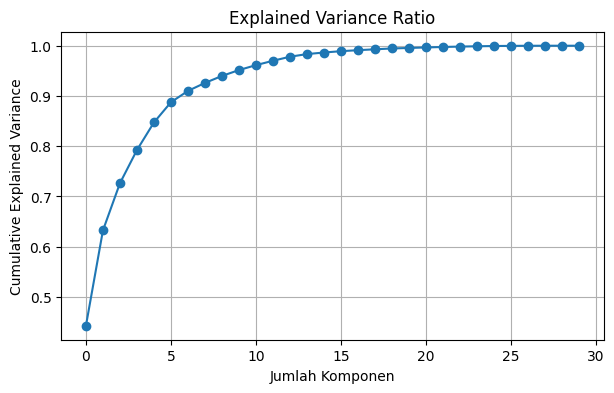

In [72]:
X_scaled = StandardScaler().fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

plt.figure(figsize=(7,4))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Ratio")
plt.grid(True)
plt.show()